# WS3 – Exercises

| # | Topic | Type |
|---|-------|------|
| 1 | Manual RMSE | code |
| 2 | Manual R² | code |
| 3 | Detect overfitting from a table | reasoning |
| 4 | Add Early Stopping to a real model | full training |
| 5 | Manual Precision, Recall, F1 | code |

---

## Exercise 1 — Manual RMSE

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n}(y_{\text{true},i} - y_{\text{pred},i})^2}$$

**Task:** Implement RMSE manually (no sklearn). Calculate for both train and val.

In [7]:
import numpy as np

y_train      = np.array([0.5, 1.2, 0.8, 1.5])
y_train_pred = np.array([0.55, 1.18, 0.82, 1.48])
y_val        = np.array([0.6, 1.1, 0.9, 1.4])
y_val_pred   = np.array([0.58, 1.12, 0.85, 1.45])

# Your code here
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
val_rmse = np.sqrt(np.mean((y_val - y_val_pred)**2))

print(f"Manual Train RMSE: {train_rmse:.4f}")
print(f"Manual Val RMSE: {val_rmse:.4f}")

Manual Train RMSE: 0.0304
Manual Val RMSE: 0.0381


---
## Exercise 2 — Manual R²

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} \qquad SS_{res} = \sum(y_{true}-y_{pred})^2 \qquad SS_{tot} = \sum(y_{true}-\bar{y})^2$$

**Task:** Implement R² manually. Same data as Exercise 1.

In [8]:
import numpy as np

y_train      = np.array([0.5, 1.2, 0.8, 1.5])
y_train_pred = np.array([0.55, 1.18, 0.82, 1.48])
y_val        = np.array([0.6, 1.1, 0.9, 1.4])
y_val_pred   = np.array([0.58, 1.12, 0.85, 1.45])

# Your code here
train_ss_res = np.sum((y_train - y_train_pred)**2)
train_ss_tot = np.sum((y_train - np.mean(y_train))**2)
train_r2 = 1 - (train_ss_res / train_ss_tot)

val_ss_res = np.sum((y_val - y_val_pred)**2)
val_ss_tot = np.sum((y_val - np.mean(y_val))**2)
val_r2 = 1 - (val_ss_res / val_ss_tot)

print(f"Manual Train R²: {train_r2:.4f}")
print(f"Manual Val R²: {val_r2:.4f}")

Manual Train R²: 0.9936
Manual Val R²: 0.9829


---
## Exercise 3 — Detect Overfitting from Metrics

| Metric | Model A Train | Model A Val | Model B Train | Model B Val |
|--------|--------------|-------------|--------------|-------------|
| MAE    | 0.15         | 0.18        | 0.08         | 0.25        |
| R²     | 0.82         | 0.79        | 0.95         | 0.68        |

Answer the questions below:
1. Which model overfits more? Why?
2. Which model would you deploy?
3. What is the Val/Train MAE ratio for each model?
4. Model B has better training R² (0.95 vs 0.82) — should you prefer it?

**Your answers:**

1. B
2. A
3. 1.2 / 3.1
4. No, sign of overfitting

---
## Exercise 4 — Add Early Stopping to a Real Model

**Task:**
1. Add `EarlyStopping` (monitor `val_loss`, patience=10, restore best weights)
2. Train up to 200 epochs
3. Print the epoch where it stopped
4. Plot train vs val loss

**Bonus:** Add `Dropout(0.3)` and `L2(0.001)` to the model — does the curve look better?

Training with Early Stopping...
Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7138 - mae: 0.5738 - val_loss: 0.3836 - val_mae: 0.4450
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3555 - mae: 0.4246 - val_loss: 0.3499 - val_mae: 0.4193
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3378 - mae: 0.4115 - val_loss: 0.3672 - val_mae: 0.4355
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3271 - mae: 0.4042 - val_loss: 0.3372 - val_mae: 0.3973
Epoch 5/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3114 - mae: 0.3910 - val_loss: 0.3379 - val_mae: 0.4055
Epoch 6/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2960 - mae: 0.3793 - val_loss: 0.3234 - val_mae: 0.3874
Epoch 7/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2929 - mae: 0.3781 - val_loss: 0.3077 - val_mae: 0.3836
Epoch 8/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2911 - mae: 0.3760 - val_loss: 0.3260 - val_mae: 0.4126
Epoch 9/200
129/

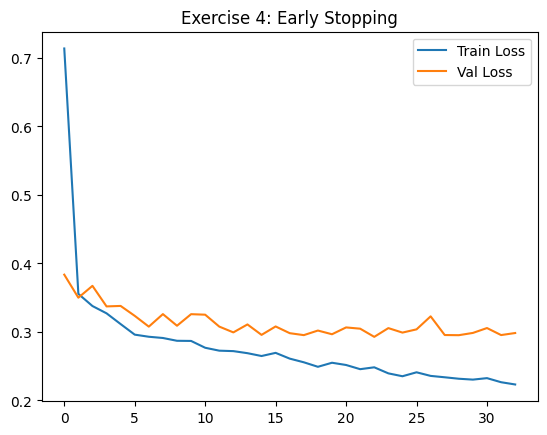

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Data Setup ---
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# --- Clean Keras 3 Model ---
model = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003), 
    loss='mse', 
    metrics=['mae']
)

# --- Early Stopping ---
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# --- Train ---
print("Training with Early Stopping...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nStopped early at epoch: {len(history.history['loss'])}")

# --- Plot ---
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Exercise 4: Early Stopping')
plt.legend()
plt.show()

---
## Exercise 5 — Manual Precision, Recall & F1

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F1 = \frac{2 \cdot P \cdot R}{P+R}$$

**Task:**
1. Count TP, FP, FN manually
2. Compute precision, recall, F1
3. Verify with `classification_report` from sklearn

**Bonus question (no code):** Why is high precision + low recall dangerous in medical diagnosis?

In [10]:
import numpy as np
from sklearn.metrics import classification_report

# 1 = high price, 0 = low price
y_true = np.array([0, 1, 0, 1, 1, 0, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0, 1, 1])

# Your code here
tp = np.sum((y_true == 1) & (y_pred == 1))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Bonus Answer: 
# high precision + low recall is dangerous because we miss many sick people. 
# In medicine, a false negative (missing a diagnosis) is usually more harmful than a false positive (a false alarm).

Precision: 0.60
Recall: 0.75
F1-Score: 0.67


**Bonus answer:**
